# Trimer

Three-site trimer with Kanamori interaction and discrete bath.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
                  alps_cthyb     atomdiag        cthyb        ctint      edipack      pomerol  w2dyn_cthyb
     alps_cthyb                  1.05e+00     9.55e-01     1.07e+00     1.06e+00     1.05e+00     9.56e-01
       atomdiag                               1.77e-01     3.42e-02     1.18e-02     1.85e-06     3.08e-01
          cthyb                                            1.77e-01     1.77e-01     1.77e-01     3.29e-01
          ctint                                                         2.68e-02     3.43e-02     3.08e-01
        edipack                                                                      1.18e-02     3.08e-01
        pomerol                                                                                   3.08e-01
    w2dyn_cthyb                                                                                           


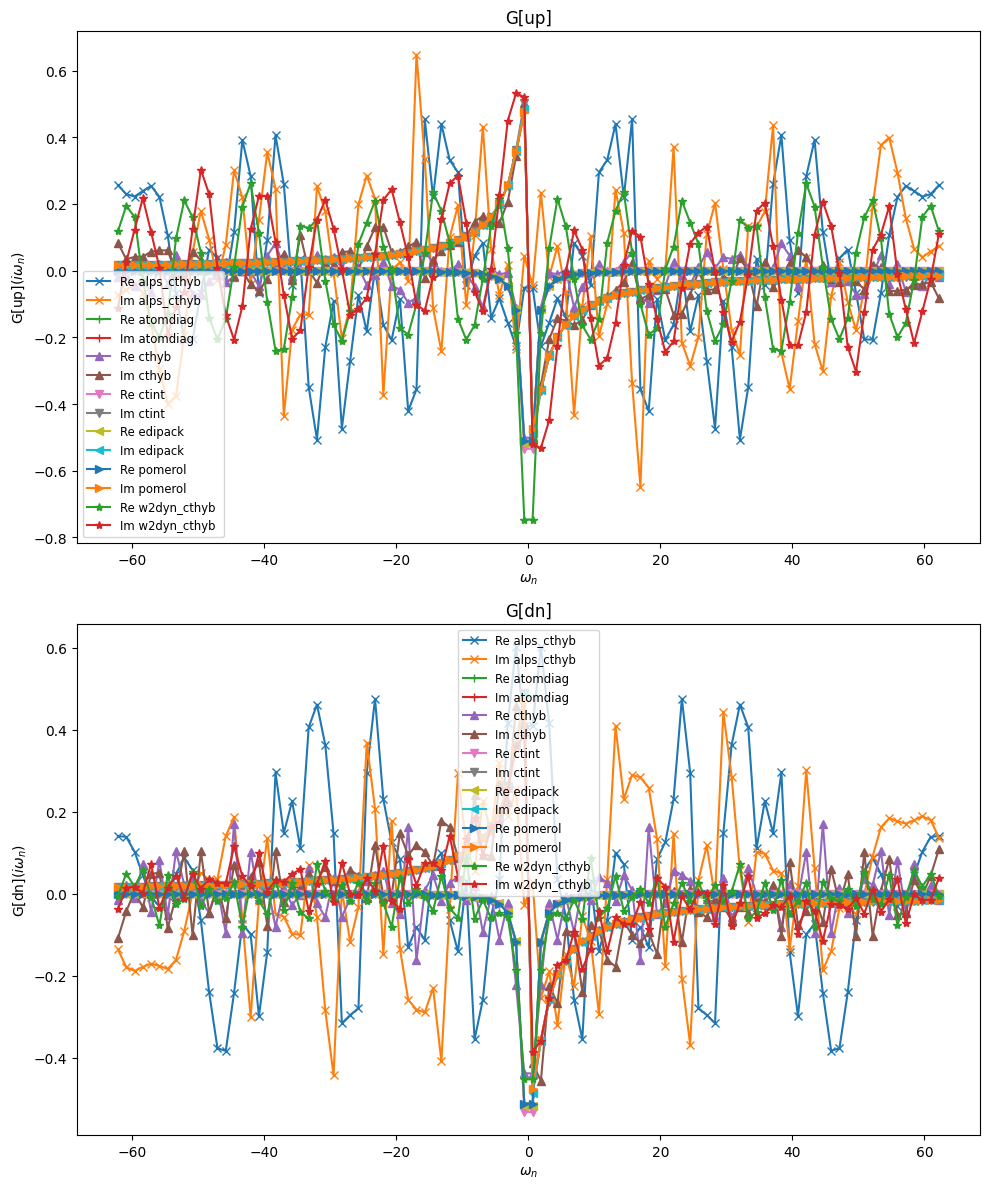

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
                  alps_cthyb     atomdiag        cthyb        ctint      edipack      pomerol  w2dyn_cthyb
     alps_cthyb                  6.59e+01     5.05e+02     6.57e+01     6.59e+01     6.59e+01     2.67e+02
       atomdiag                               4.86e+02     1.29e+00     2.66e-02     7.52e-04     2.77e+02
          cthyb                                            4.86e+02     4.86e+02     4.86e+02     5.11e+02
          ctint                                                         1.29e+00     1.29e+00     2.77e+02
        edipack                                                                      2.66e-02     2.77e+02
        pomerol                                                                                   2.77e+02
    w2dyn_cthyb                                                                                           


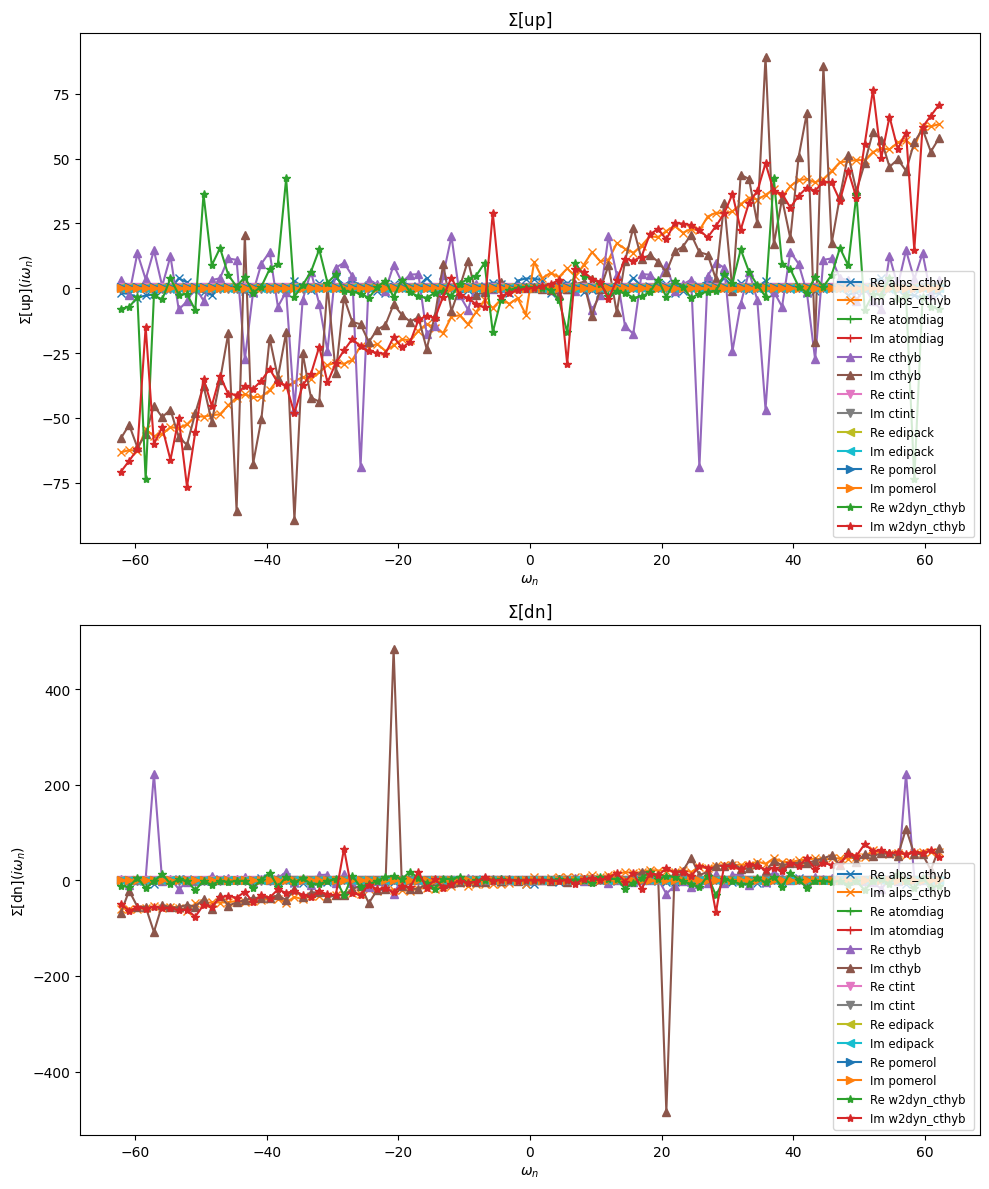

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    atomdiag              dn_0: 0.187867, dn_1: 0.174914, dn_2: 0.162899, up_0: 0.187867, up_1: 0.174914, up_2: 0.162899
    cthyb                 dn_0: 0.187798, dn_1: 0.172179, dn_2: 0.162660, up_0: 0.187907, up_1: 0.173377, up_2: 0.162524
    ctint                 dn_0: 0.174694, dn_1: 0.156719, dn_2: 0.155717, up_0: 0.167519, up_1: 0.160440, up_2: 0.150186
    edipack               dn_0: 0.177650, dn_1: 0.166039, dn_2: 0.155357, up_0: 0.177650, up_1: 0.166039, up_2: 0.155357
    pomerol               dn_0: 0.187867+0.000000j, dn_1: 0.174914+0.000000j, dn_2: 0.162899+0.000000j, up_0: 0.187867+0.000000j, up_1: 0.174914+0.000000j, up_2: 0.162899+0.000000j

  nn_ab:
    atomdiag              dn_0,dn_0: 0.187867, dn_0,dn_1: 0.008104, dn_0,dn_2: 0.006336, dn_0,up_0: 0.030356, dn_0,up_1: 0.032355, dn_0,up_2: 0.030202, dn_1,dn_0: 0.008104, dn_1,dn_1: 0.174914, dn_1,dn_2: 0.004696, dn_1,up_0: 0.032355, dn_1,up_1: 0.026287, dn_1,up_2: 0.028155, dn_2,dn_0: 0.006336, dn_2,dn_1: 0.0

## 4. Real-Frequency Spectral Function $A(\omega)$

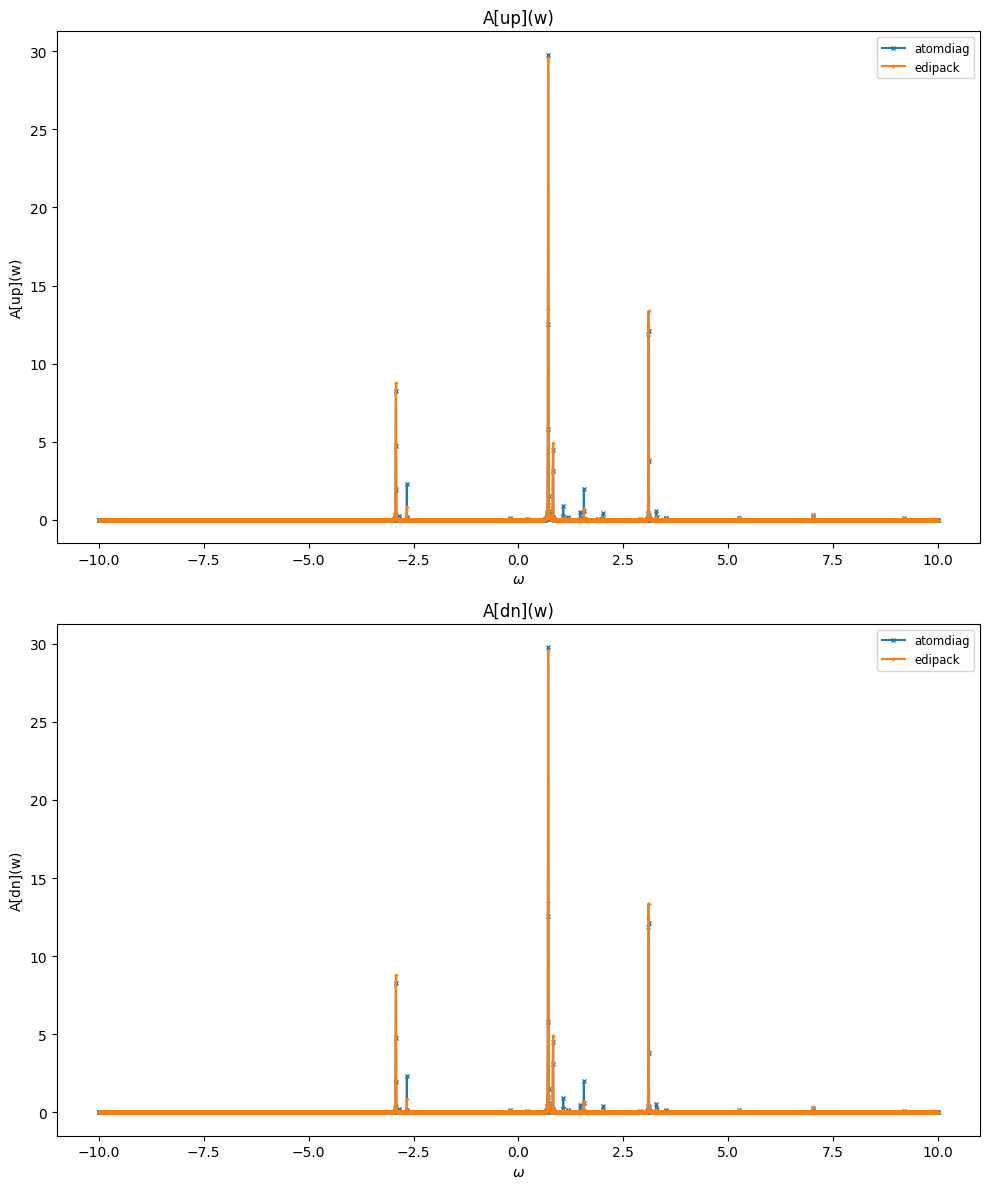

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

## 5. Three-Point Correlator $\chi_3$

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)